In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models
from PIL import Image
import os
from sklearn.model_selection import train_test_split

In [3]:
image_folder = r"C:\img_align_celeba"

images = []

for file in os.listdir(image_folder)[:5000]:
    if file.endswith(".jpg"):
        img = Image.open(
            os.path.join(image_folder, file)
        ).convert("L")

        img = img.resize((28, 28))
        images.append(np.array(img))

x = np.array(images)

print("Images:", x.shape)

Images: (3374, 28, 28)


In [4]:
x = x.astype("float32") / 255.0

x_train, x_test = train_test_split(
    x,
    test_size=0.2,
    random_state=42
)

print("Training images:", x_train.shape)
print("Testing images:", x_test.shape)

Training images: (2699, 28, 28)
Testing images: (675, 28, 28)


In [5]:
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

print("Training image shape:", x_train.shape)

Training image shape: (2699, 28, 28, 1)


In [6]:
encoder = models.Sequential([
    
    layers.Input(shape=(28,28,1)),

    layers.Conv2D(
        32,
        (3,3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPooling2D((2,2)),

    layers.Conv2D(
        64,
        (3,3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPooling2D((2,2))
])

encoder.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 28, 28, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 14, 14, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 7, 7, 64)            │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 18,816 (73.50 KB)

 Trainable params: 18,816 (73.50 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
decoder = models.Sequential([

    layers.Conv2DTranspose(
        64,
        (3,3),
        strides=2,
        activation="relu",
        padding="same"
    ),

    layers.Conv2DTranspose(
        32,
        (3,3),
        strides=2,
        activation="relu",
        padding="same"
    ),

    layers.Conv2D(
        1,
        (3,3),
        activation="sigmoid",
        padding="same"
    )

])

decoder.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_transpose (Conv2DTranspose)   │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose_1 (Conv2DTranspose) │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [8]:
autoencoder = models.Sequential([
    encoder,
    decoder
])

autoencoder.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential (Sequential)              │ (None, 7, 7, 64)            │          18,816 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sequential_1 (Sequential)            │ (None, 28, 28, 1)           │          55,681 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
autoencoder = models.Sequential([
    encoder,
    decoder
])

autoencoder.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential (Sequential)              │ (None, 7, 7, 64)            │          18,816 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sequential_1 (Sequential)            │ (None, 28, 28, 1)           │          55,681 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
autoencoder.compile(
    optimizer="adam",
    loss="binary_crossentropy"
)

In [11]:
history = autoencoder.fit(
    x_train,
    x_train,
    epochs=3,
    batch_size=128,
    validation_data=(x_test, x_test)
)

Epoch 1/3
22/22 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - loss: 0.6687 - val_loss: 0.6071
Epoch 2/3
22/22 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - loss: 0.5709 - val_loss: 0.5579
Epoch 3/3
22/22 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - loss: 0.5476 - val_loss: 0.5441


In [12]:
reconstructed = autoencoder.predict(x_test[:5])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 644ms/step


In [13]:
print("Minimum:", reconstructed.min())
print("Maximum:", reconstructed.max())
print("Mean:", reconstructed.mean())

Minimum: 0.034038197
Maximum: 0.9355485
Mean: 0.4430097


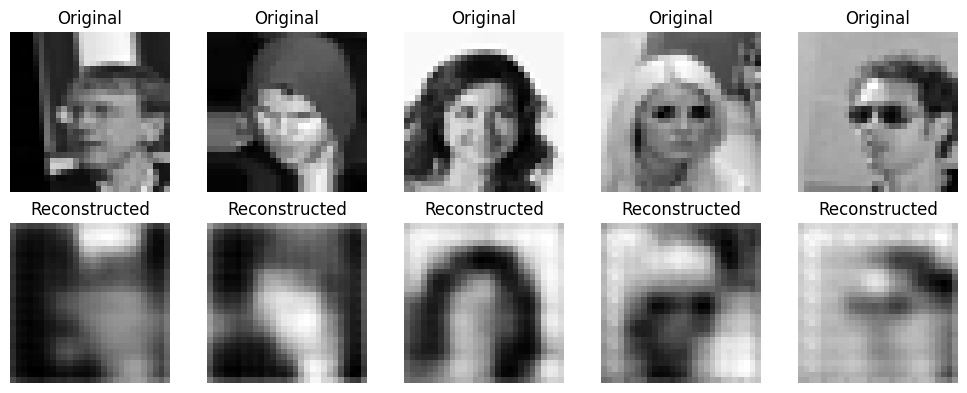

In [14]:
plt.figure(figsize=(10,4))

for i in range(5):

    plt.subplot(2,5,i+1)
    plt.imshow(x_test[i].squeeze(), cmap="gray")
    plt.axis("off")
    plt.title("Original")

    plt.subplot(2,5,i+6)
    plt.imshow(reconstructed[i].squeeze(), cmap="gray")
    plt.axis("off")
    plt.title("Reconstructed")

plt.tight_layout()
plt.show()